Part 1: Complete Binary Classification Workflow

Step 1: Creating data...
Step 2: Splitting data...
Step 3: Converting to tensors...
Step 4: Using device: cpu
Step 5: Building model...
Step 6: Setting up loss and optimizer...


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Step 7: Training model...
  Epoch [20/100], Train Loss: 0.6375, Test Loss: 0.6380
  Epoch [40/100], Train Loss: 0.4433, Test Loss: 0.4594
  Epoch [60/100], Train Loss: 0.1603, Test Loss: 0.1719
  Epoch [80/100], Train Loss: 0.0372, Test Loss: 0.0436
  Epoch [100/100], Train Loss: 0.0126, Test Loss: 0.0159
Step 8: Evaluating model...
Binary Classification Accuracy: 100.00%

Part 2: Complete Multi-Class Workflow

Creating multi-class data...
Training multi-class model...
  Epoch [20/100], Loss: 0.6416
  Epoch [40/100], Loss: 0.0708
  Epoch [60/100], Loss: 0.0058
  Epoch [80/100], Loss: 0.0034
  Epoch [100/100], Loss: 0.0029
Multi-class Accuracy: 100.00%

Part 3: Hyperparameter Experimentation

Testing different configurations:
  Config 1: hidden=[8], lr=0.01, Accuracy: 95.00%
  Config 2: hidden=[16], lr=0.01, Accuracy: 100.00%
  Config 3: hidden=[16, 8], lr=0.01, Accuracy: 100.00%
  Config 4: hidden=[32, 16], lr=0.001, Accuracy: 100.00%
  Config 5: hidden=[64, 32, 16], lr=0.001, Accuracy

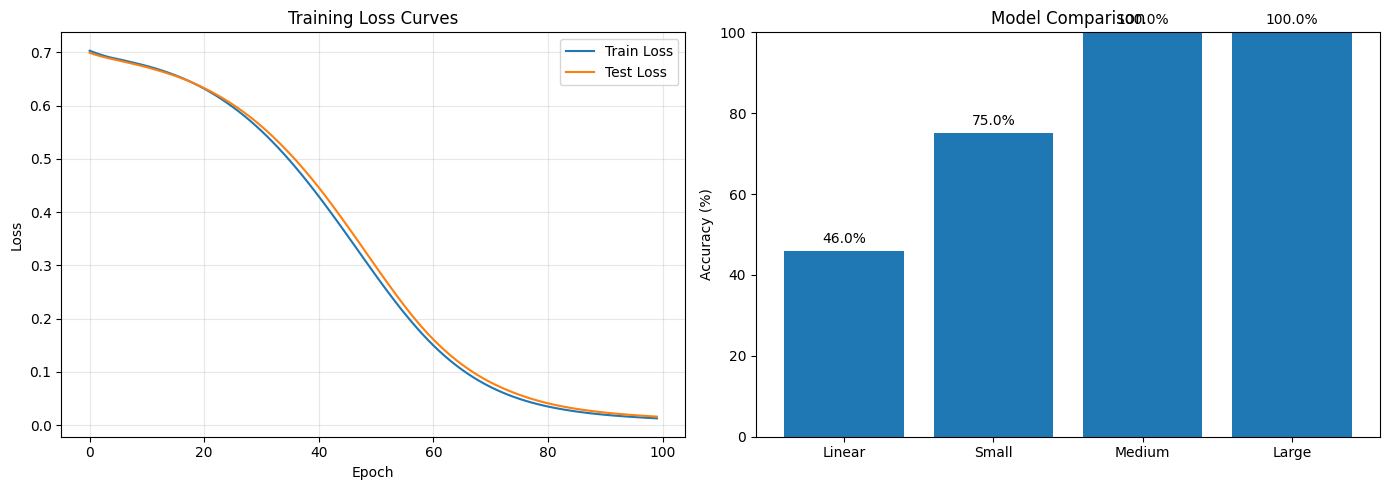


Exercises

Exercise 1: Design your own experiment
Create and test your own model configuration:
  - Try different architectures
  - Try different learning rates
  - Try different numbers of epochs
Tip: Use the ClassificationTrainer class

Exercise 2: Compare on different datasets
Test models on different datasets:
  - make_circles with different noise levels
  - make_blobs with different number of classes
Tip: Modify the data creation code

Exercise 3: Implement early stopping
Stop training when test loss stops improving:
  - Track test loss each epoch
  - Stop if no improvement for N epochs
Tip: Add patience parameter to training loop

Exercise 4: Create model comparison report
Compare models and create a report:
  - Test accuracy
  - Number of parameters
  - Training time
Tip: Track training time with time.time()

Exercise 5: Save/load with metadata
Save model with additional information:
  - Hyperparameters
  - Training metrics
  - Date/time
Tip: Use pickle or create a dictionary t

In [1]:
"""
Exercise 6: Complete Classification Workflow
Neural Network Classification - Module 3

This exercise covers:
- End-to-end binary classification workflow
- End-to-end multi-class workflow
- Hyperparameter experimentation
- Model comparison and selection
- Saving and loading trained models

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import pickle
from pathlib import Path

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================
# Part 1: Complete Binary Classification Workflow
# ============================================

print("=" * 60)
print("Part 1: Complete Binary Classification Workflow")
print("=" * 60)

# Step 1: Create data
print("\nStep 1: Creating data...")
X, y = make_circles(n_samples=1000, noise=0.03, factor=0.5, random_state=42)

# Step 2: Split data
print("Step 2: Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Convert to tensors
print("Step 3: Converting to tensors...")
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Step 4: Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Step 4: Using device: {device}")

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Step 5: Define model
print("Step 5: Building model...")
class BinaryClassifier(nn.Module):
    def __init__(self, hidden_units=[16, 8]):
        super(BinaryClassifier, self).__init__()
        layers = []
        prev_size = 2
        for hidden_size in hidden_units:
            layers.extend([nn.Linear(prev_size, hidden_size), nn.ReLU()])
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

model = BinaryClassifier(hidden_units=[16, 8]).to(device)

# Step 6: Define loss and optimizer
print("Step 6: Setting up loss and optimizer...")
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Step 7: Train model
print("Step 7: Training model...")
epochs = 100
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train)
    loss = criterion(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = criterion(test_logits, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'  Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

# Step 8: Evaluate
print("Step 8: Evaluating model...")
model.eval()
with torch.inference_mode():
    test_probs = torch.sigmoid(model(X_test))
    test_preds = (test_probs > 0.5).long()

accuracy = (test_preds == y_test).float().mean()
print(f"Binary Classification Accuracy: {accuracy.item()*100:.2f}%")

# ============================================
# Part 2: Complete Multi-Class Workflow
# ============================================

print("\n" + "=" * 60)
print("Part 2: Complete Multi-Class Workflow")
print("=" * 60)

# Create multi-class data
print("\nCreating multi-class data...")
X_multi, y_multi = make_blobs(n_samples=1000, n_features=2, centers=4, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

X_train_m = torch.FloatTensor(X_train_m)
y_train_m = torch.LongTensor(y_train_m)
X_test_m = torch.FloatTensor(X_test_m)
y_test_m = torch.LongTensor(y_test_m)

X_train_m, y_train_m = X_train_m.to(device), y_train_m.to(device)
X_test_m, y_test_m = X_test_m.to(device), y_test_m.to(device)

# Define multi-class model
class MultiClassClassifier(nn.Module):
    def __init__(self, num_classes=4, hidden_units=[16, 8]):
        super(MultiClassClassifier, self).__init__()
        layers = []
        prev_size = 2
        for hidden_size in hidden_units:
            layers.extend([nn.Linear(prev_size, hidden_size), nn.ReLU()])
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

model_m = MultiClassClassifier(num_classes=4, hidden_units=[16, 8]).to(device)

# Train
print("Training multi-class model...")
criterion_m = nn.CrossEntropyLoss()
optimizer_m = optim.Adam(model_m.parameters(), lr=0.01)

for epoch in range(100):
    model_m.train()
    outputs = model_m(X_train_m)
    loss = criterion_m(outputs, y_train_m)
    optimizer_m.zero_grad()
    loss.backward()
    optimizer_m.step()

    if (epoch + 1) % 20 == 0:
        print(f'  Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Evaluate
model_m.eval()
with torch.inference_mode():
    test_preds_m = torch.argmax(model_m(X_test_m), dim=1)

accuracy_m = (test_preds_m == y_test_m).float().mean()
print(f"Multi-class Accuracy: {accuracy_m.item()*100:.2f}%")

# ============================================
# Part 3: Hyperparameter Experimentation
# ============================================

print("\n" + "=" * 60)
print("Part 3: Hyperparameter Experimentation")
print("=" * 60)

def train_and_evaluate(hidden_units, learning_rate, epochs=100):
    """Train model with given hyperparameters"""
    # Create model
    model = BinaryClassifier(hidden_units=hidden_units).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Train
    for epoch in range(epochs):
        model.train()
        y_logits = model(X_train)
        loss = criterion(y_logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    with torch.inference_mode():
        test_preds = (torch.sigmoid(model(X_test)) > 0.5).long()
        accuracy = (test_preds == y_test).float().mean()

    return accuracy.item()

# Experiment with different configurations
configs = [
    {'hidden_units': [8], 'lr': 0.01},
    {'hidden_units': [16], 'lr': 0.01},
    {'hidden_units': [16, 8], 'lr': 0.01},
    {'hidden_units': [32, 16], 'lr': 0.001},
    {'hidden_units': [64, 32, 16], 'lr': 0.001},
]

print("\nTesting different configurations:")
results = []
for i, config in enumerate(configs):
    acc = train_and_evaluate(config['hidden_units'], config['lr'])
    results.append({**config, 'accuracy': acc})
    print(f"  Config {i+1}: hidden={config['hidden_units']}, lr={config['lr']}, Accuracy: {acc*100:.2f}%")

# Find best configuration
best_config = max(results, key=lambda x: x['accuracy'])
print(f"\nBest configuration: {best_config}")

# ============================================
# Part 4: Model Comparison
# ============================================

print("\n" + "=" * 60)
print("Part 4: Model Comparison")
print("=" * 60)

# Train multiple models
models = {
    'Linear': BinaryClassifier(hidden_units=[]),
    'Small': BinaryClassifier(hidden_units=[8]),
    'Medium': BinaryClassifier(hidden_units=[16, 8]),
    'Large': BinaryClassifier(hidden_units=[32, 16]),
}

print("\nComparing different model sizes:")
comparison_results = {}

for name, model_comp in models.items():
    model_comp = model_comp.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model_comp.parameters(), lr=0.01)

    # Train
    for epoch in range(100):
        model_comp.train()
        y_logits = model_comp(X_train)
        loss = criterion(y_logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model_comp.eval()
    with torch.inference_mode():
        test_preds = (torch.sigmoid(model_comp(X_test)) > 0.5).long()
        accuracy = (test_preds == y_test).float().mean()
        params = sum(p.numel() for p in model_comp.parameters())

    comparison_results[name] = {
        'accuracy': accuracy.item(),
        'parameters': params
    }
    print(f"  {name:8s}: Accuracy={accuracy.item()*100:5.2f}%, Parameters={params:,}")

# ============================================
# Part 5: Saving and Loading Models
# ============================================

print("\n" + "=" * 60)
print("Part 5: Saving and Loading Models")
print("=" * 60)

# Create directory for saving models
model_dir = Path('saved_models')
model_dir.mkdir(exist_ok=True)

# Save model state dict
model_path = model_dir / 'binary_classifier.pth'
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

# Load model
loaded_model = BinaryClassifier(hidden_units=[16, 8])
loaded_model.load_state_dict(torch.load(model_path))
loaded_model = loaded_model.to(device)
loaded_model.eval()
print("Model loaded successfully!")

# Verify loaded model works
with torch.inference_mode():
    test_preds_loaded = (torch.sigmoid(loaded_model(X_test)) > 0.5).long()
    accuracy_loaded = (test_preds_loaded == y_test).float().mean()
print(f"Loaded model accuracy: {accuracy_loaded.item()*100:.2f}%")

# Save complete model (including architecture)
complete_model_path = model_dir / 'binary_classifier_complete.pth'
torch.save(model, complete_model_path)
print(f"Complete model saved to: {complete_model_path}")

# Load complete model
loaded_complete = torch.load(complete_model_path)
loaded_complete.eval()
print("Complete model loaded successfully!")

# ============================================
# Part 6: Model Inference Function
# ============================================

print("\n" + "=" * 60)
print("Part 6: Model Inference Function")
print("=" * 60)

def predict(model, X_new, device='cpu'):
    """Make predictions on new data"""
    model.eval()
    model = model.to(device)

    # Convert to tensor if needed
    if not isinstance(X_new, torch.Tensor):
        X_new = torch.FloatTensor(X_new)

    X_new = X_new.to(device)

    # Make prediction
    with torch.inference_mode():
        logits = model(X_new)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()

    return {
        'logits': logits.cpu(),
        'probabilities': probs.cpu(),
        'predictions': preds.cpu()
    }

# Test inference function
X_new = torch.randn(5, 2)
results = predict(model, X_new, device)

print("\nPredictions for 5 new samples:")
for i in range(5):
    print(f"  Sample {i+1}:")
    print(f"    Input: {X_new[i].numpy()}")
    print(f"    Probability: {results['probabilities'][i].item():.4f}")
    print(f"    Predicted class: {results['predictions'][i].item()}")

# ============================================
# Part 7: Complete Training Class
# ============================================

print("\n" + "=" * 60)
print("Part 7: Complete Training Class")
print("=" * 60)

class ClassificationTrainer:
    """Complete training pipeline for classification"""

    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.history = {'train_loss': [], 'test_loss': []}

    def train(self, X_train, y_train, X_test, y_test,
              epochs=100, lr=0.01):
        """Train the model"""
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=lr)

        for epoch in range(epochs):
            # Training
            self.model.train()
            y_logits = self.model(X_train)
            loss = criterion(y_logits, y_train)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Testing
            self.model.eval()
            with torch.inference_mode():
                test_logits = self.model(X_test)
                test_loss = criterion(test_logits, y_test)

            self.history['train_loss'].append(loss.item())
            self.history['test_loss'].append(test_loss.item())

            if (epoch + 1) % 20 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

    def evaluate(self, X_test, y_test):
        """Evaluate the model"""
        self.model.eval()
        with torch.inference_mode():
            test_probs = torch.sigmoid(self.model(X_test))
            test_preds = (test_probs > 0.5).long()
            accuracy = (test_preds == y_test).float().mean()

        return accuracy.item()

    def save(self, path):
        """Save the model"""
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load(self, path):
        """Load the model"""
        self.model.load_state_dict(torch.load(path))
        print(f"Model loaded from: {path}")

# Use the trainer
print("\nUsing ClassificationTrainer:")
model_trainer = BinaryClassifier(hidden_units=[16, 8])
trainer = ClassificationTrainer(model_trainer, device=device)
trainer.train(X_train, y_train, X_test, y_test, epochs=100, lr=0.01)
accuracy_trainer = trainer.evaluate(X_test, y_test)
print(f"Final accuracy: {accuracy_trainer*100:.2f}%")

# Save the trained model
trainer.save(model_dir / 'trained_classifier.pth')

# ============================================
# Part 8: Training Curves Visualization
# ============================================

print("\n" + "=" * 60)
print("Part 8: Training Curves Visualization")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses, label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Model comparison
names = list(comparison_results.keys())
accuracies = [comparison_results[name]['accuracy'] * 100 for name in names]
axes[1].bar(names, accuracies)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Model Comparison')
axes[1].set_ylim(0, 100)
for i, v in enumerate(accuracies):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# ============================================
# Exercises
# ============================================

print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Design your own experiment
print("\nExercise 1: Design your own experiment")
print("Create and test your own model configuration:")
print("  - Try different architectures")
print("  - Try different learning rates")
print("  - Try different numbers of epochs")
print("Tip: Use the ClassificationTrainer class")

# Exercise 2: Compare on different datasets
print("\nExercise 2: Compare on different datasets")
print("Test models on different datasets:")
print("  - make_circles with different noise levels")
print("  - make_blobs with different number of classes")
print("Tip: Modify the data creation code")

# Exercise 3: Implement early stopping
print("\nExercise 3: Implement early stopping")
print("Stop training when test loss stops improving:")
print("  - Track test loss each epoch")
print("  - Stop if no improvement for N epochs")
print("Tip: Add patience parameter to training loop")

# Exercise 4: Create model comparison report
print("\nExercise 4: Create model comparison report")
print("Compare models and create a report:")
print("  - Test accuracy")
print("  - Number of parameters")
print("  - Training time")
print("Tip: Track training time with time.time()")

# Exercise 5: Save/load with metadata
print("\nExercise 5: Save/load with metadata")
print("Save model with additional information:")
print("  - Hyperparameters")
print("  - Training metrics")
print("  - Date/time")
print("Tip: Use pickle or create a dictionary to save")

print("\n" + "=" * 60)
print("Exercise 6 Complete!")
print("Remember: If in doubt, run the code!")
print("Remember: Experiment, experiment, experiment!")
print("Remember: Visualize, visualize, visualize!")
print("=" * 60)


# Exercise 1: Design your own experiment
Create and test your own model configuration:
- Try different architectures
- Try different learning rates
- Try different numbers of epochs

In [2]:
configs = [
    {'hidden_units': [4],          'lr': 0.1,   'epochs': 50},
    {'hidden_units': [16, 16],     'lr': 0.005, 'epochs': 200},
    {'hidden_units': [32, 16, 8],  'lr': 0.001, 'epochs': 150},
]

results = []
for cfg in configs:
    model = BinaryClassifier(hidden_units=cfg['hidden_units'])
    trainer = ClassificationTrainer(model, device=device)

    print("\n" + "-"*40)
    print(f"training with {cfg}")
    trainer.train(X_train, y_train, X_test, y_test,
                epochs=cfg['epochs'], lr=cfg['lr'])
    acc = trainer.evaluate(X_test, y_test)
    print(f"final accuracy: {acc*100:.2f}%")
    results.append({**cfg, 'accuracy': acc})

# you can inspect results list or plot as desired
print("\nsummary of experiments:")
for r in results:
    print(r)


----------------------------------------
training with {'hidden_units': [4], 'lr': 0.1, 'epochs': 50}
Epoch [20/50], Train Loss: 0.4922, Test Loss: 0.5032
Epoch [40/50], Train Loss: 0.1212, Test Loss: 0.1204
final accuracy: 100.00%

----------------------------------------
training with {'hidden_units': [16, 16], 'lr': 0.005, 'epochs': 200}
Epoch [20/200], Train Loss: 0.5970, Test Loss: 0.5934
Epoch [40/200], Train Loss: 0.4043, Test Loss: 0.4034
Epoch [60/200], Train Loss: 0.1710, Test Loss: 0.1754
Epoch [80/200], Train Loss: 0.0564, Test Loss: 0.0616
Epoch [100/200], Train Loss: 0.0238, Test Loss: 0.0277
Epoch [120/200], Train Loss: 0.0132, Test Loss: 0.0162
Epoch [140/200], Train Loss: 0.0087, Test Loss: 0.0110
Epoch [160/200], Train Loss: 0.0063, Test Loss: 0.0081
Epoch [180/200], Train Loss: 0.0048, Test Loss: 0.0063
Epoch [200/200], Train Loss: 0.0038, Test Loss: 0.0051
final accuracy: 100.00%

----------------------------------------
training with {'hidden_units': [32, 16, 8], 

# Exercise 2: Compare on different datasets
Test models on different datasets:
- make_circles with different noise levels
- make_blobs with different number of classes


In [3]:
# helper for circle datasets (binary)
def experiment_circles(noise_levels, factor=0.5, n_samples=1000):
    results = {}
    for noise in noise_levels:
        X, y = make_circles(n_samples=n_samples,
                            noise=noise,
                            factor=factor,
                            random_state=42)
        Xtr, Xte, ytr, yte = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        Xtr = torch.FloatTensor(Xtr).to(device)
        ytr = torch.FloatTensor(ytr).unsqueeze(1).to(device)
        Xte = torch.FloatTensor(Xte).to(device)
        yte = torch.FloatTensor(yte).unsqueeze(1).to(device)

        model = BinaryClassifier(hidden_units=[16, 8])
        trainer = ClassificationTrainer(model, device=device)
        trainer.train(Xtr, ytr, Xte, yte, epochs=100, lr=0.01)
        acc = trainer.evaluate(Xte, yte)
        results[noise] = acc
        print(f"noise {noise}: acc {acc*100:.2f}%")
    return results

noise_levels = [0.01, 0.03, 0.05, 0.1]
print("=== make_circles experiments ===")
noise_results = experiment_circles(noise_levels)

# helper for blob datasets (multi‑class)
def experiment_blobs(centers_list, n_samples=1000):
    results = {}
    for centers in centers_list:
        X, y = make_blobs(n_samples=n_samples,
                        n_features=2,
                        centers=centers,
                        random_state=42)
        Xtr, Xte, ytr, yte = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        Xtr = torch.FloatTensor(Xtr).to(device)
        ytr = torch.LongTensor(ytr).to(device)
        Xte = torch.FloatTensor(Xte).to(device)
        yte = torch.LongTensor(yte).to(device)

        model = MultiClassClassifier(num_classes=centers, hidden_units=[16, 8]).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.01)

        # simple training loop
        for epoch in range(100):
            model.train()
            outputs = model(Xtr)
            loss = criterion(outputs, ytr)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.inference_mode():
            preds = torch.argmax(model(Xte), dim=1)
            acc = (preds == yte).float().mean().item()
        results[centers] = acc
        print(f"centers {centers}: acc {acc*100:.2f}%")
    return results

centers_list = [2, 3, 4, 5]
print("\n=== make_blobs experiments ===")
blob_results = experiment_blobs(centers_list)

print("\nsummary:")
print("circle noise → accuracy", noise_results)
print("blob centers → accuracy", blob_results)

=== make_circles experiments ===
Epoch [20/100], Train Loss: 0.5664, Test Loss: 0.5619
Epoch [40/100], Train Loss: 0.2652, Test Loss: 0.2582
Epoch [60/100], Train Loss: 0.0519, Test Loss: 0.0480
Epoch [80/100], Train Loss: 0.0111, Test Loss: 0.0109
Epoch [100/100], Train Loss: 0.0050, Test Loss: 0.0050
noise 0.01: acc 100.00%
Epoch [20/100], Train Loss: 0.6185, Test Loss: 0.6169
Epoch [40/100], Train Loss: 0.3474, Test Loss: 0.3530
Epoch [60/100], Train Loss: 0.0721, Test Loss: 0.0728
Epoch [80/100], Train Loss: 0.0150, Test Loss: 0.0166
Epoch [100/100], Train Loss: 0.0064, Test Loss: 0.0077
noise 0.03: acc 100.00%
Epoch [20/100], Train Loss: 0.6654, Test Loss: 0.6618
Epoch [40/100], Train Loss: 0.5635, Test Loss: 0.5620
Epoch [60/100], Train Loss: 0.3318, Test Loss: 0.3329
Epoch [80/100], Train Loss: 0.0988, Test Loss: 0.1092
Epoch [100/100], Train Loss: 0.0285, Test Loss: 0.0361
noise 0.05: acc 100.00%
Epoch [20/100], Train Loss: 0.5707, Test Loss: 0.5737
Epoch [40/100], Train Loss: 

# Exercise 3: Implement early stopping
Stop training when test loss stops improving:
- Track test loss each epoch
- Stop if no improvement for N epochs

epoch 20/200  train_loss=0.6180  test_loss=0.6174
epoch 40/200  train_loss=0.3898  test_loss=0.3855
epoch 60/200  train_loss=0.1349  test_loss=0.1364
epoch 80/200  train_loss=0.0343  test_loss=0.0378
epoch 100/200  train_loss=0.0120  test_loss=0.0143
epoch 120/200  train_loss=0.0049  test_loss=0.0061
epoch 140/200  train_loss=0.0020  test_loss=0.0026
epoch 160/200  train_loss=0.0010  test_loss=0.0014
epoch 180/200  train_loss=0.0006  test_loss=0.0009
epoch 200/200  train_loss=0.0004  test_loss=0.0006
accuracy after early stopping: 100.00%


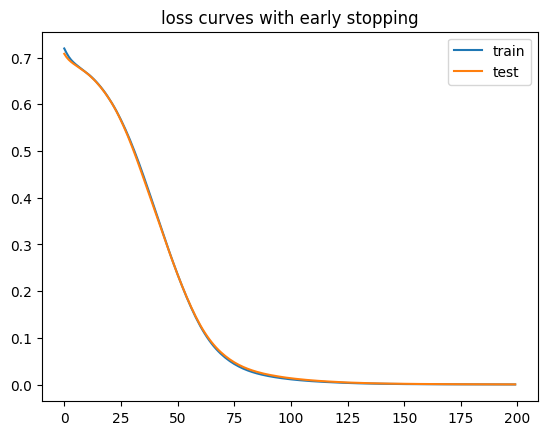

In [4]:
# simple early‑stopping training loop
def train_with_early_stopping(model,
                            X_train, y_train,
                            X_test, y_test,
                            epochs=100,
                            lr=0.01,
                            patience=10):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'test_loss': []}
    best_state = None

    for epoch in range(epochs):
        # training step
        model.train()
        logits = model(X_train)
        loss = criterion(logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        history['train_loss'].append(loss.item())

        # evaluation on validation/test set
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test)
            test_loss = criterion(test_logits, y_test)
        history['test_loss'].append(test_loss.item())

        # check for improvement
        if test_loss.item() < best_loss - 1e-8:
            best_loss = test_loss.item()
            epochs_no_improve = 0
            best_state = model.state_dict()
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            if best_state is not None:
                model.load_state_dict(best_state)
            break

        if (epoch + 1) % 20 == 0:
            print(f"epoch {epoch+1}/{epochs}  train_loss={loss.item():.4f}  test_loss={test_loss.item():.4f}")

    return history

# example usage
model_es = BinaryClassifier(hidden_units=[16, 8])
history_es = train_with_early_stopping(model_es,
                                    X_train, y_train,
                                    X_test, y_test,
                                    epochs=200,
                                    lr=0.01,
                                    patience=20)

# evaluate after early stopping
model_es.eval()
with torch.inference_mode():
    preds_es = (torch.sigmoid(model_es(X_test)) > 0.5).long()
accuracy_es = (preds_es == y_test).float().mean()
print(f"accuracy after early stopping: {accuracy_es.item()*100:.2f}%")

# inspect history if you like
plt.plot(history_es['train_loss'], label='train')
plt.plot(history_es['test_loss'], label='test')
plt.legend()
plt.title('loss curves with early stopping')
plt.show()

# Exercise 4: Create model comparison report
Compare models and create a report:
- Test accuracy
- Number of parameters
- Training time

In [5]:
import time

models = {
    'Linear': BinaryClassifier(hidden_units=[]),
    'Small': BinaryClassifier(hidden_units=[8]),
    'Medium': BinaryClassifier(hidden_units=[16, 8]),
    'Large': BinaryClassifier(hidden_units=[32, 16]),
}

report = []
epochs = 100
for name, model in models.items():
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    start_time = time.time()
    model.train()
    for _ in range(epochs):
        logits = model(X_train)
        loss = criterion(logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_time = time.time() - start_time

    model.eval()
    with torch.inference_mode():
        preds = (torch.sigmoid(model(X_test)) > 0.5).long()
        accuracy = (preds == y_test).float().mean().item()
    params = sum(p.numel() for p in model.parameters())

    report.append({'model': name, 'accuracy': accuracy, 'parameters': params, 'train_time_sec': train_time})
    print(f"{name:6s} | Accuracy: {accuracy*100:6.2f}% | Params: {params:,} | Time: {train_time:.2f}s")

# Summary sorted by accuracy
report = sorted(report, key=lambda x: x['accuracy'], reverse=True)
print("\nSummary (sorted by accuracy):")
for r in report:
    print(r)

Linear | Accuracy:  46.00% | Params: 3 | Time: 0.06s
Small  | Accuracy:  99.50% | Params: 33 | Time: 0.07s
Medium | Accuracy: 100.00% | Params: 193 | Time: 0.10s
Large  | Accuracy: 100.00% | Params: 641 | Time: 0.19s

Summary (sorted by accuracy):
{'model': 'Medium', 'accuracy': 1.0, 'parameters': 193, 'train_time_sec': 0.10479283332824707}
{'model': 'Large', 'accuracy': 1.0, 'parameters': 641, 'train_time_sec': 0.19033312797546387}
{'model': 'Small', 'accuracy': 0.9950000047683716, 'parameters': 33, 'train_time_sec': 0.07311654090881348}
{'model': 'Linear', 'accuracy': 0.46000000834465027, 'parameters': 3, 'train_time_sec': 0.060675859451293945}


# Exercise 5: Save/load with metadata
Save model with additional information:
- Hyperparameters
- Training metrics
- Date/time

In [6]:
from datetime import datetime

def save_model_with_metadata(path, model, metadata=None):
    data = {} if metadata is None else dict(metadata)
    data.update({
        'state_dict': model.state_dict(),
        'num_parameters': sum(p.numel() for p in model.parameters()),
        'saved_at': datetime.utcnow().isoformat() + 'Z'
    })
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Saved model+metadata to: {path}")

def load_model_with_metadata(path, model=None, map_location=None):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    if model is not None:
        model.load_state_dict(data['state_dict'], strict=True)
    return data

# Example usage (uses existing objects in the notebook):
metadata = {
    'hyperparameters': {
        'hidden_units': [16, 8],
        'lr': 0.01,
        'epochs': len(trainer.history['train_loss']) if hasattr(trainer, 'history') else None
    },
    'training_metrics': trainer.history if hasattr(trainer, 'history') else None,
    'dataset': 'make_circles'
}

save_path = model_dir / 'binary_with_metadata.pkl'
save_model_with_metadata(save_path, trainer.model, metadata=metadata)

loaded = load_model_with_metadata(save_path)
# to load into a model instance:
# fresh = BinaryClassifier(hidden_units=[16,8])
# load_model_with_metadata(save_path, model=fresh)

Saved model+metadata to: saved_models\binary_with_metadata.pkl
